In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

# 분석 CSV 데이터 불러오기
path = '/content/drive/MyDrive/교통문제공모전/final_merged.csv'
df = pd.read_csv(path, encoding='utf-8')
display(df.head(5))
df.info()

,행정동별 코드,행정동명,평균 출근시간,평균 퇴근시간,평균 출퇴근시간,시도,시군구,읍면동,name,full_name,중위매매가
0,1101053,서울특별시 종로구 사직동,41.856243,43.714615,42.785429,11000,11010,1101053,사직동,서울특별시 종로구 사직동,1033000
1,1101054,서울특별시 종로구 삼청동,41.163624,44.502380,42.833002,11000,11010,1101054,삼청동,서울특별시 종로구 삼청동,1033000
2,1101055,서울특별시 종로구 부암동,48.528843,47.098866,47.813854,11000,11010,1101055,부암동,서울특별시 종로구 부암동,1033000
3,1101056,서울특별시 종로구 평창동,54.670017,52.057281,53.363649,11000,11010,1101056,평창동,서울특별시 종로구 평창동,1033000
4,1101057,서울특별시 종로구 무악동,45.938625,47.381531,46.660078,11000,11010,1101057,무악동,서울특별시 종로구 무악동,1033000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   행정동별 코드    1128 non-null   int64  
 1   행정동명       1128 non-null   object 
 2   평균 출근시간    1128 non-null   float64
 3   평균 퇴근시간    1128 non-null   float64
 4   평균 출퇴근시간   1128 non-null   float64
 5   시도         1128 non-null   int64  
 6   시군구        1128 non-null   int64  
 7   읍면동        1128 non-null   int64  
 8   name       1128 non-null   object 
 9   full_name  1128 non-null   object 
 10  중위매매가      1128 non-null   int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 97.1+ KB


**분석 전, '시군구별 경제활동인구' 데이터 추가**
- 읍면동별 데이터 부재-> 시군구로 대체.
- 지역에 맞춰 행정동코드 기준으로 final_merged와 데이터셋 JOIN -> 최종 분석용 set 생성
- 이 데이터를 왜 추가했는가? -> 출퇴근 시간만 가지고는 섣불리 교통 인프라 확충을 판단할 수 없다고 생각. (Ex. 연천군과 평택시 둘 다 출퇴근 시간이 오래 걸리는데, 인프라를 동일하게 놓는 게 합리적인가? 평택시가 인구는 훨씬 많음)

In [ ]:
# 시군구별 경제활동인구 데이터 csv 불러오기
eco_path = '/content/drive/MyDrive/교통문제공모전/시군구_경제활동인구_총괄_2026상.csv'
edf = pd.read_csv(eco_path, encoding='cp949')
display(edf.head(5))
edf.info()

,행정구역코드,행정구역별,15세이상인구 (천명),경제활동인구 (천명),취업자 (천명),경제활동참가율 (％),고용률 (%)
0,1101,서울 종로구,134,73,70,54.4,51.8
1,1102,서울 중구,117,71,69,60.6,58.7
2,1103,서울 용산구,183,115,111,62.9,60.5
3,1104,서울 성동구,252,157,153,62.3,60.6
4,1105,서울 광진구,318,201,192,63.2,60.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   행정구역코드        66 non-null     int64  
 1   행정구역별         66 non-null     object 
 2   15세이상인구 (천명)  66 non-null     int64  
 3   경제활동인구 (천명)   66 non-null     int64  
 4   취업자 (천명)      66 non-null     int64  
 5   경제활동참가율 (％)   66 non-null     float64
 6   고용률 (%)       66 non-null     float64
dtypes: float64(2), int64(4), object(1)
memory usage: 3.7+ KB


In [ ]:
# 두 데이터셋 조인
df['시군구코드'] = df['행정동별 코드'].astype(str).str[:4]
edf['시군구코드'] = edf['행정구역코드'].astype(str)

final_df = pd.merge(df, edf, on='시군구코드', how='left')

display(final_df.head())
final_df.info()

,행정동별 코드,행정동명,평균 출근시간,평균 퇴근시간,평균 출퇴근시간,시도,시군구,읍면동,name,full_name,중위매매가,시군구코드,행정구역코드,행정구역별,15세이상인구 (천명),경제활동인구 (천명),취업자 (천명),경제활동참가율 (％),고용률 (%)
0,1101053,서울특별시 종로구 사직동,41.856243,43.714615,42.785429,11000,11010,1101053,사직동,서울특별시 종로구 사직동,1033000,1101,1101,서울 종로구,134,73,70,54.4,51.8
1,1101054,서울특별시 종로구 삼청동,41.163624,44.502380,42.833002,11000,11010,1101054,삼청동,서울특별시 종로구 삼청동,1033000,1101,1101,서울 종로구,134,73,70,54.4,51.8
2,1101055,서울특별시 종로구 부암동,48.528843,47.098866,47.813854,11000,11010,1101055,부암동,서울특별시 종로구 부암동,1033000,1101,1101,서울 종로구,134,73,70,54.4,51.8
3,1101056,서울특별시 종로구 평창동,54.670017,52.057281,53.363649,11000,11010,1101056,평창동,서울특별시 종로구 평창동,1033000,1101,1101,서울 종로구,134,73,70,54.4,51.8
4,1101057,서울특별시 종로구 무악동,45.938625,47.381531,46.660078,11000,11010,1101057,무악동,서울특별시 종로구 무악동,1033000,1101,1101,서울 종로구,134,73,70,54.4,51.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   행정동별 코드       1128 non-null   int64  
 1   행정동명          1128 non-null   object 
 2   평균 출근시간       1128 non-null   float64
 3   평균 퇴근시간       1128 non-null   float64
 4   평균 출퇴근시간      1128 non-null   float64
 5   시도            1128 non-null   int64  
 6   시군구           1128 non-null   int64  
 7   읍면동           1128 non-null   int64  
 8   name          1128 non-null   object 
 9   full_name     1128 non-null   object 
 10  중위매매가         1128 non-null   int64  
 11  시군구코드         1128 non-null   object 
 12  행정구역코드        1128 non-null   int64  
 13  행정구역별         1128 non-null   object 
 14  15세이상인구 (천명)  1128 non-null   int64  
 15  경제활동인구 (천명)   1128 non-null   int64  
 16  취업자 (천명)      1128 non-null   int64  
 17  경제활동참가율 (％)   1128 non-null   float64
 18  고용률 (%)       1128 non-null 

In [ ]:
columns_to_drop = ['시도','읍면동','full_name','시군구','행정구역코드','행정구역별']

final_df = final_df.drop(columns=columns_to_drop)
display(final_df.head())
final_df.info()

,행정동별 코드,행정동명,평균 출근시간,평균 퇴근시간,평균 출퇴근시간,name,중위매매가,시군구코드,15세이상인구 (천명),경제활동인구 (천명),취업자 (천명),경제활동참가율 (％),고용률 (%)
0,1101053,서울특별시 종로구 사직동,41.856243,43.714615,42.785429,사직동,1033000,1101,134,73,70,54.4,51.8
1,1101054,서울특별시 종로구 삼청동,41.163624,44.502380,42.833002,삼청동,1033000,1101,134,73,70,54.4,51.8
2,1101055,서울특별시 종로구 부암동,48.528843,47.098866,47.813854,부암동,1033000,1101,134,73,70,54.4,51.8
3,1101056,서울특별시 종로구 평창동,54.670017,52.057281,53.363649,평창동,1033000,1101,134,73,70,54.4,51.8
4,1101057,서울특별시 종로구 무악동,45.938625,47.381531,46.660078,무악동,1033000,1101,134,73,70,54.4,51.8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   행정동별 코드       1128 non-null   int64  
 1   행정동명          1128 non-null   object 
 2   평균 출근시간       1128 non-null   float64
 3   평균 퇴근시간       1128 non-null   float64
 4   평균 출퇴근시간      1128 non-null   float64
 5   name          1128 non-null   object 
 6   중위매매가         1128 non-null   int64  
 7   시군구코드         1128 non-null   object 
 8   15세이상인구 (천명)  1128 non-null   int64  
 9   경제활동인구 (천명)   1128 non-null   int64  
 10  취업자 (천명)      1128 non-null   int64  
 11  경제활동참가율 (％)   1128 non-null   float64
 12  고용률 (%)       1128 non-null   float64
dtypes: float64(5), int64(5), object(3)
memory usage: 114.7+ KB


In [ ]:
# 생성된 최종 데이터셋 저장
final_df.to_csv('final_dataset.csv', index=False, encoding='utf-8-sig')
print("'final_dataset.csv'로 저장되었습니다")

'final_dataset.csv'로 저장되었습니다


**시군구 타지역 통근 데이터 추가**
- 분석에 더 알맞다고 판단되는 데이터 발견, 추가
- 추가 칼럼: `거주지내 통근 취업자 (천명)`, `거주지외 타지역 통근 취업자 (천명)` (시군구 단위, 두 값의 합 = 취업자)
- 기존 `경제활동인구` / `취업자` 대신, 실제로 시군구 밖으로 통근하는 사람 수(`거주지외 타지역 통근 취업자`)를 지역 규모 변수로 사용

In [ ]:
# 시군구별 거주지내/거주지외 통근 취업자 데이터 csv 불러오기
com_path = '/content/drive/MyDrive/교통문제공모전/시군구_타지역_통근_취업자_20260921161748.csv'
mdf = pd.read_csv(com_path, encoding='cp949')
display(mdf.head(5))
mdf.info()

COM_IN  = '거주지내 통근 취업자 (천명)'
COM_OUT = '거주지외 타지역 통근 취업자 (천명)'

# 검증: 거주지내 + 거주지외 = 취업자 (천명 단위 반올림 때문에 1 이내 차이는 정상)
gap = (mdf[COM_IN] + mdf[COM_OUT] - mdf['취업자 (천명)']).abs()
print(f"\n(거주지내 + 거주지외) - 취업자 최대 차이: {gap.max()}천명")

,코드,행정구역별,취업자 (천명),거주지내 통근 취업자 (천명),거주지외 타지역 통근 취업자 (천명)
0,1101,서울 종로구,70,28,42
1,1102,서울 중구,69,30,39
2,1103,서울 용산구,111,36,74
3,1104,서울 성동구,153,53,100
4,1105,서울 광진구,192,63,129


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   코드                    66 non-null     int64 
 1   행정구역별                 66 non-null     object
 2   취업자 (천명)              66 non-null     int64 
 3   거주지내 통근 취업자 (천명)      66 non-null     int64 
 4   거주지외 타지역 통근 취업자 (천명)  66 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.7+ KB

(거주지내 + 거주지외) - 취업자 최대 차이: 1천명


In [ ]:
final_df['시군구코드'] = final_df['행정동별 코드'].astype(str).str[:4]
mdf['시군구코드'] = mdf['코드'].astype(str)

# '취업자 (천명)'은 final_df에 이미 있으므로 제외 (그대로 조인하면 _x, _y로 갈라져 이후 코드가 깨짐)
mdf_use = mdf[['시군구코드', COM_IN, COM_OUT]]

# 1차: 시군구코드로 조인
final_set = pd.merge(final_df, mdf_use, on='시군구코드', how='left')

# 파생변수: 타지역 통근 비율(%) = 거주지외 / (거주지내 + 거주지외)
final_set['타지역 통근 비율 (%)'] = final_set[COM_OUT] / (final_set[COM_IN] + final_set[COM_OUT]) * 100

display(final_set.head())
final_set.info()

,행정동별 코드,행정동명,평균 출근시간,평균 퇴근시간,평균 출퇴근시간,name,중위매매가,시군구코드,15세이상인구 (천명),경제활동인구 (천명),취업자 (천명),경제활동참가율 (％),고용률 (%),거주지내 통근 취업자 (천명),거주지외 타지역 통근 취업자 (천명),타지역 통근 비율 (%)
0,1101053,서울특별시 종로구 사직동,41.856243,43.714615,42.785429,사직동,1033000,1101,134,73,70,54.4,51.8,28,42,60.0
1,1101054,서울특별시 종로구 삼청동,41.163624,44.502380,42.833002,삼청동,1033000,1101,134,73,70,54.4,51.8,28,42,60.0
2,1101055,서울특별시 종로구 부암동,48.528843,47.098866,47.813854,부암동,1033000,1101,134,73,70,54.4,51.8,28,42,60.0
3,1101056,서울특별시 종로구 평창동,54.670017,52.057281,53.363649,평창동,1033000,1101,134,73,70,54.4,51.8,28,42,60.0
4,1101057,서울특별시 종로구 무악동,45.938625,47.381531,46.660078,무악동,1033000,1101,134,73,70,54.4,51.8,28,42,60.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   행정동별 코드               1128 non-null   int64  
 1   행정동명                  1128 non-null   object 
 2   평균 출근시간               1128 non-null   float64
 3   평균 퇴근시간               1128 non-null   float64
 4   평균 출퇴근시간              1128 non-null   float64
 5   name                  1128 non-null   object 
 6   중위매매가                 1128 non-null   int64  
 7   시군구코드                 1128 non-null   object 
 8   15세이상인구 (천명)          1128 non-null   int64  
 9   경제활동인구 (천명)           1128 non-null   int64  
 10  취업자 (천명)              1128 non-null   int64  
 11  경제활동참가율 (％)           1128 non-null   float64
 12  고용률 (%)               1128 non-null   float64
 13  거주지내 통근 취업자 (천명)      1128 non-null   int64  
 14  거주지외 타지역 통근 취업자 (천명)  1128 non-null   int64  
 15  타지역 통근 비율 (%)        

In [ ]:
# 생성된 진짜 최종 데이터셋 저장
final_set.to_csv('real_final_dataset.csv', index=False, encoding='utf-8-sig')
print("'real_final_dataset.csv'로 저장되었습니다")
real_final_path = '/content/drive/MyDrive/교통문제공모전/real_final_dataset.csv'
final_set.to_csv(real_final_path, index=False, encoding='utf-8-sig')

'real_final_dataset.csv'로 저장되었습니다


#**분석**

In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# NanumGothic 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

In [ ]:
# 한글 폰트 설정: NanumGothic 폰트를 직접 등록하고 rcParams에 설정
font_name = 'NanumGothic'
font_prop = None
font_found_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf' # 이전 실행 결과에서 찾은 경로

if os.path.exists(font_found_path):
    try:
        # Matplotlib의 fontManager에 폰트 직접 추가
        fm.fontManager.addfont(font_found_path)
        font_prop = fm.FontProperties(fname=font_found_path)

        # rcParams에 폰트 설정. NanumGothic을 우선순위에 두고 다른 sans-serif 폰트를 fallback으로 지정.
        plt.rcParams['font.family'] = ['NanumGothic', 'sans-serif']
        plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

        print(f"Font '{font_name}' successfully added and set for rcParams from path: {font_found_path}")
        print(f"Current font.family rcParam: {plt.rcParams['font.family']}")

    except Exception as e:
        print(f"Error during font registration or rcParams setting: {e}. Falling back to default Matplotlib font.")
        font_prop = None
else:
    print(f"Error: Font file not found at {font_found_path}. Please ensure 'fonts-nanum' is installed and runtime restarted.")
    print("Falling back to default Matplotlib font, Korean characters may not display.")

Font 'NanumGothic' successfully added and set for rcParams from path: /usr/share/fonts/truetype/nanum/NanumGothic.ttf
Current font.family rcParam: ['NanumGothic', 'sans-serif']


- 군 단위 지역(Ex. 가평군, 인천 옹진군)은 중위매매가 데이터가 부재하므로, 각 지역의 인접 지역 데이터로 대체
- - 경기도 연천군 - 같은 경기 경원권에 속하는 인접 지역 ‘동두천시’ 데이터인 160,000(천원)으로 대체
- - 경기도 양평군 - 같은 경기 동부권에 속하는 인접 지역 ‘이천시’ 데이터인 175,000(천원)으로 대체
- - 경기도 가평군 - 같은 경기 북부권에 속하는 인접 지역  ‘포천시’ 데이터인 158,500(천원)으로 대체
- - 인천광역시 옹진군, 강화군 - 위 지역들은 아파트가 거의 없는 지역으로, 인천광역시 연립/다세대주택 중위매매가인 88,750(천원)으로 대체

In [ ]:
final_set.loc[(final_set['행정동명'].str.contains('인천광역시 강화군')) | (final_set['행정동명'].str.contains('인천광역시 옹진군')), '중위매매가'] = 88750
final_set.loc[(final_set['행정동명'].str.contains('경기도 가평군')), '중위매매가'] = 158500
final_set.loc[(final_set['행정동명'].str.contains('경기도 양평군')), '중위매매가'] = 175000
final_set.loc[(final_set['행정동명'].str.contains('경기도 연천군')), '중위매매가'] = 160000

In [ ]:
# 지역 규모 변수 설정
# 기존: 통계적 잡음 필터 = 경제활동인구 (천명) / WLS 가중치·충격 규모 = 취업자 (천명)
# 변경: 셋 다 '거주지외 타지역 통근 취업자 (천명)' -> 실제로 시군구 밖으로 통근하는(장통근 가능성이 있는) 사람 수
# 다른 변수로 바꿔 보고 싶으면 이 한 줄만 수정하면 분석 3·4가 모두 따라감
SCALE_COL = COM_OUT

print(f"규모 변수: {SCALE_COL}")
print(f"결측 행정동: {final_set[SCALE_COL].isna().sum()}개")
display(final_set[SCALE_COL].describe())

규모 변수: 거주지외 타지역 통근 취업자 (천명)
결측 행정동: 0개


,거주지외 타지역 통근 취업자 (천명)
count,1128.000000
mean,142.593972
std,77.415197
min,1.000000
25%,98.000000
50%,140.000000
75%,183.000000
max,322.000000


**분석 1: 단순 선형회귀 및 잔차 분석**
- 집값 때문에 장통근을 하는 지역은 어디인가?
- 잔차가 길다는 것은 통근시간이 길다는 뜻

In [ ]:
import pandas as pd
import numpy as np
import io
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. 단순 선형회귀 및 잔차(Residual) 분석
# ---------------------------------------------------------
X = sm.add_constant(final_set['중위매매가'])
y = final_set['평균 출퇴근시간']
model = sm.OLS(y, X).fit()
print(model.summary())

# 예측 통근시간 및 잔차(실제 통근시간 - 예측 통근시간) 계산
final_set['predicted_commute'] = model.predict(X)
final_set['residual'] = final_set['평균 출퇴근시간'] - final_set['predicted_commute']

print("=== 이중고 후보 지역 Top 10 (잔차 상위) ===")
top_10 = final_set.sort_values('residual', ascending=False).head(10)
display(top_10[['행정동명', '중위매매가', '평균 출퇴근시간', 'residual']])

                            OLS Regression Results                            
Dep. Variable:               평균 출퇴근시간   R-squared:                       0.448
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     914.4
Date:                Mon, 21 Sep 2026   Prob (F-statistic):          1.57e-147
Time:                        09:24:17   Log-Likelihood:                -4821.5
No. Observations:                1128   AIC:                             9647.
Df Residuals:                    1126   BIC:                             9657.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.9854      0.851    111.566      0.0

,행정동명,중위매매가,평균 출퇴근시간,residual
995,경기도 이천시 율면,175000,168.040390,77.603199
1002,경기도 안성시 금광면,157500,164.507164,73.615157
776,경기도 평택시 신장2동,244500,152.506332,63.875411
1114,경기도 가평군 북면,158500,153.312767,62.446749
1083,경기도 포천시 이동면,158500,149.074257,58.208239
1124,경기도 양평군 양동면,175000,141.809059,51.371868
1035,경기도 화성시 송산면,376000,135.660316,50.447014
1085,경기도 포천시 관인면,158500,138.852501,47.986483
565,인천광역시 강화군 교동면,88750,140.596176,47.917391
1097,경기도 여주시 강천면,146000,137.016853,45.825967


**분석 2: 행정동 유형 분류(사분면 분석)**


=== 지역 유형 분포 ===


,count
type,
고가-단통근,494
저가-장통근 (이중고),493
고가-장통근,71
저가-단통근,70


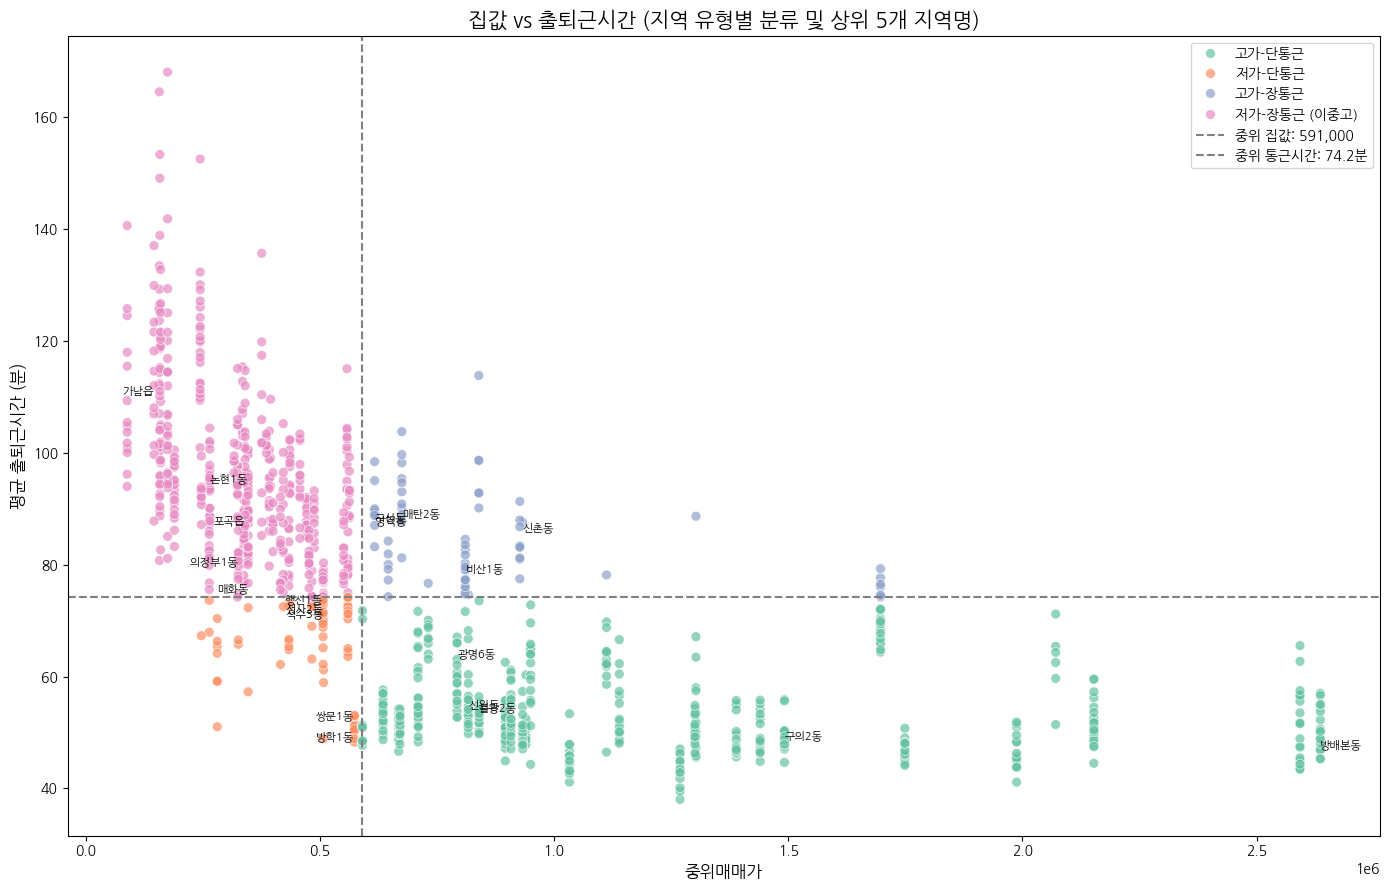

In [ ]:
# ---------------------------------------------------------
# 2. 행정동 유형 분류 (사분면 분석)
# ---------------------------------------------------------
median_price = final_set['중위매매가'].median()
median_commute = final_set['평균 출퇴근시간'].median()

def classify_region(row):
    if row['중위매매가'] >= median_price and row['평균 출퇴근시간'] < median_commute:
        return '고가-단통근'
    elif row['중위매매가'] < median_price and row['평균 출퇴근시간'] >= median_commute:
        return '저가-장통근 (이중고)'
    elif row['중위매매가'] >= median_price and row['평균 출퇴근시간'] >= median_commute:
        return '고가-장통근'
    else:
        return '저가-단통근'

final_set['type'] = final_set.apply(classify_region, axis=1)

print("\n=== 지역 유형 분포 ===")
display(final_set['type'].value_counts())

# 4. 시각화 (산점도)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(14, 9))
sns.scatterplot(data=final_set, x='중위매매가', y='평균 출퇴근시간', hue='type', palette='Set2', s=50, alpha=0.7)

# 중위값 기준 보조선 추가
plt.axvline(median_price, color='gray', linestyle='--', label=f'중위 집값: {median_price:,.0f}')
plt.axhline(median_commute, color='gray', linestyle='--', label=f'중위 통근시간: {median_commute:.1f}분')

# 각 사분면별로 5개씩 무작위 지역명 추가
for region_type in final_set['type'].unique():
    # 해당 유형의 데이터프레임 서브셋 생성
    subset_quadrant = final_set[final_set['type'] == region_type]

    # 해당 서브셋이 비어있지 않은 경우에만 샘플링
    if not subset_quadrant.empty:
        # 5개 또는 서브셋 크기 중 작은 값으로 샘플링
        sample_size = min(5, len(subset_quadrant))
        random_sample = subset_quadrant.sample(n=sample_size, random_state=42) # 재현성을 위해 random_state 설정

        # 샘플링된 지역에 대해 텍스트 라벨 추가
        for i, row in random_sample.iterrows():
            # 텍스트 위치 조정을 위해 사분면별로 ha, va 값 조정
            if region_type == '고가-단통근': # 우상단 (집값 높고 통근시간 짧음)
                ha = 'left'
                va = 'bottom'
            elif region_type == '저가-장통근 (이중고)': # 좌하단 (집값 낮고 통근시간 김)
                ha = 'right'
                va = 'top'
            elif region_type == '고가-장통근': # 우하단 (집값 높고 통근시간 김)
                ha = 'left'
                va = 'top'
            else: # 저가-단통근: 좌상단 (집값 낮고 통근시간 짧음)
                ha = 'right'
                va = 'bottom'
            plt.text(row['중위매매가'], row['평균 출퇴근시간'], row['name'],
                     fontsize=8, ha=ha, va=va, color='black') # 텍스트 색상을 검정으로 통일

plt.title('집값 vs 출퇴근시간 (지역 유형별 분류 및 상위 5개 지역명)', fontsize=15)
plt.xlabel('중위매매가', fontsize=12)
plt.ylabel('평균 출퇴근시간 (분)', fontsize=12)
plt.legend()
plt.tight_layout()

# 그래프 저장 및 출력
plt.savefig('scatter_with_quadrant_labels.png', dpi=300)
plt.show()

=== 사분면 분류(type) vs K-means 군집 교차표 ===


kmeans_cluster,0,1,2,3
type,,,,
고가-단통근,367,121,0,6
고가-장통근,1,7,2,61
저가-단통근,24,0,0,46
저가-장통근 (이중고),0,0,181,312



'이중고' 지역의 63.3%가 K-means 군집 3에 집중


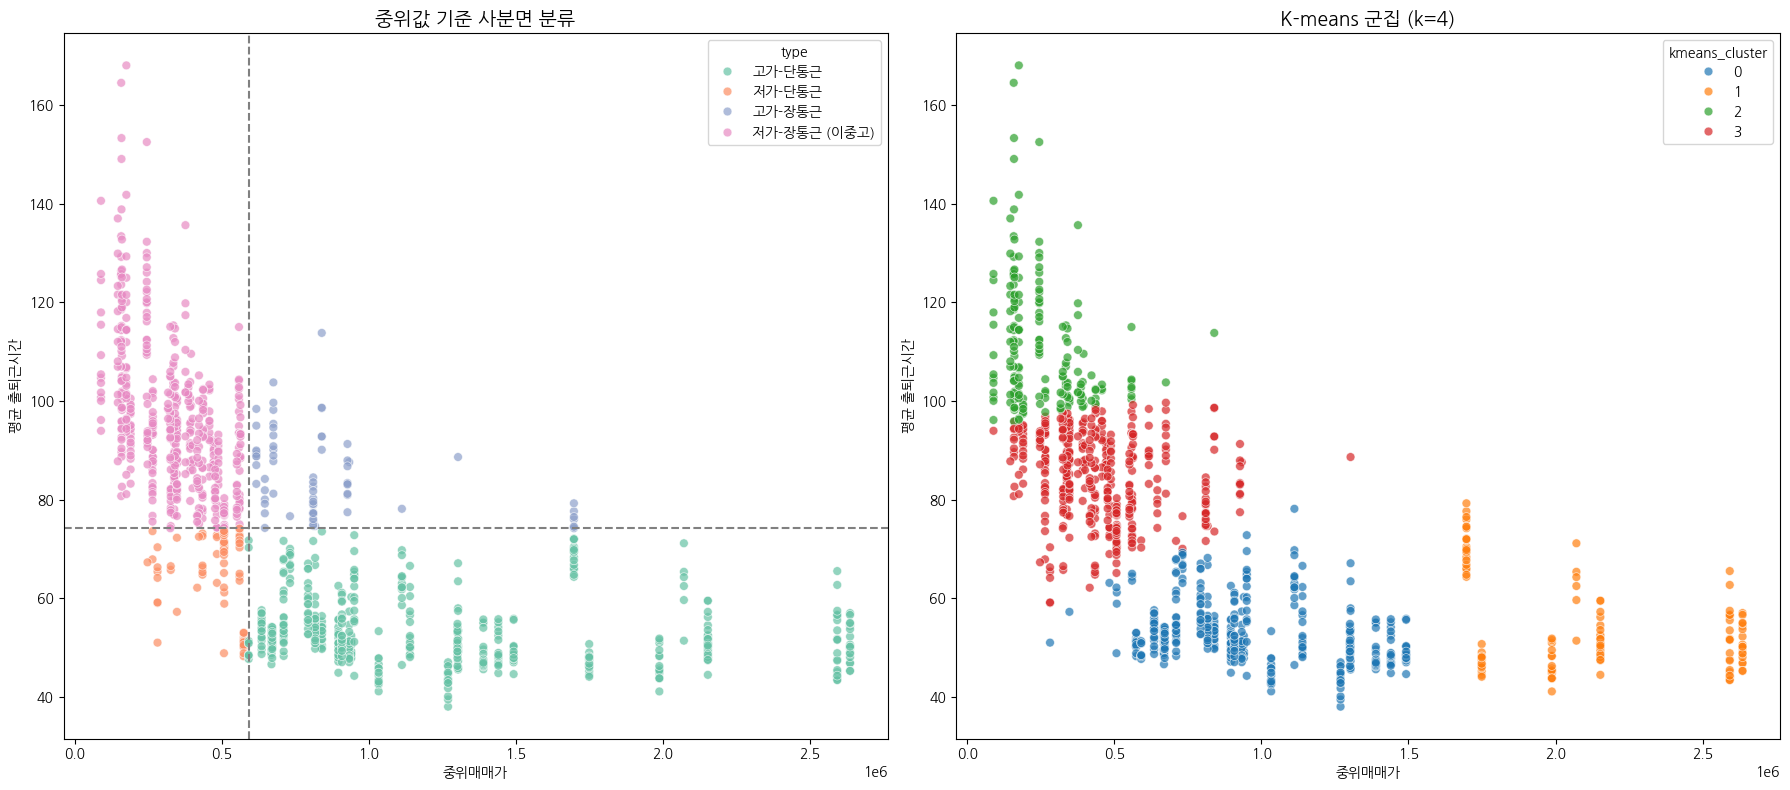

In [ ]:
# K-means 클러스터링을 통한 사분면 분류(type) 교차검증
# -> 중위값 기준 사분면 분류가 인위적 기준이 아니라 데이터 자체의 군집 구조와도 부합하는지 확인
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_vars = final_set[['중위매매가', '평균 출퇴근시간']].copy()

scaler = StandardScaler()
cluster_vars_scaled = scaler.fit_transform(cluster_vars)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_set['kmeans_cluster'] = kmeans.fit_predict(cluster_vars_scaled)

print("=== 사분면 분류(type) vs K-means 군집 교차표 ===")
cross_tab = pd.crosstab(final_set['type'], final_set['kmeans_cluster'])
display(cross_tab)

# '저가-장통근 (이중고)'로 분류된 지역이 특정 군집에 얼마나 집중되어 있는지 확인
dual_burden_cross = cross_tab.loc['저가-장통근 (이중고)']
dominant_cluster = dual_burden_cross.idxmax()
concentration = dual_burden_cross.max() / dual_burden_cross.sum() * 100
print(f"\n'이중고' 지역의 {concentration:.1f}%가 K-means 군집 {dominant_cluster}에 집중")

# 시각화: 중위값 기준 분류 vs K-means 군집 비교
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.scatterplot(data=final_set, x='중위매매가', y='평균 출퇴근시간', hue='type',
                 palette='Set2', s=40, alpha=0.7, ax=axes[0])
axes[0].axvline(median_price, color='gray', linestyle='--')
axes[0].axhline(median_commute, color='gray', linestyle='--')
axes[0].set_title('중위값 기준 사분면 분류', fontsize=14)

sns.scatterplot(data=final_set, x='중위매매가', y='평균 출퇴근시간', hue='kmeans_cluster',
                 palette='tab10', s=40, alpha=0.7, ax=axes[1])
axes[1].set_title('K-means 군집 (k=4)', fontsize=14)

plt.tight_layout()
plt.show()

**분석 3: 이중고 지역 내 통계적 잡음 제외 분석**
- 이중고 지역 중 상당수는 인구 자체가 적은 산간/소멸위기 지역임.
- 따라서, 거주지외 타지역 통근 취업자 규모를 기준으로 표본이 지나치게 적은 지역은 별도로 구분 (하위 25% 기준)

=== 컷오프 임계값별 정책 우선순위 지역 수 ===


,분위수 컷오프,정책 우선순위 지역 수
0,10%,393
1,15%,366
2,20%,356
3,25%,307
4,30%,298
5,33%,281



=== 25% 기준 대비 자카드 유사도 (지역 목록 안정성) ===
10% 기준: 자카드 유사도 0.781
15% 기준: 자카드 유사도 0.839
20% 기준: 자카드 유사도 0.862
30% 기준: 자카드 유사도 0.971
33% 기준: 자카드 유사도 0.915


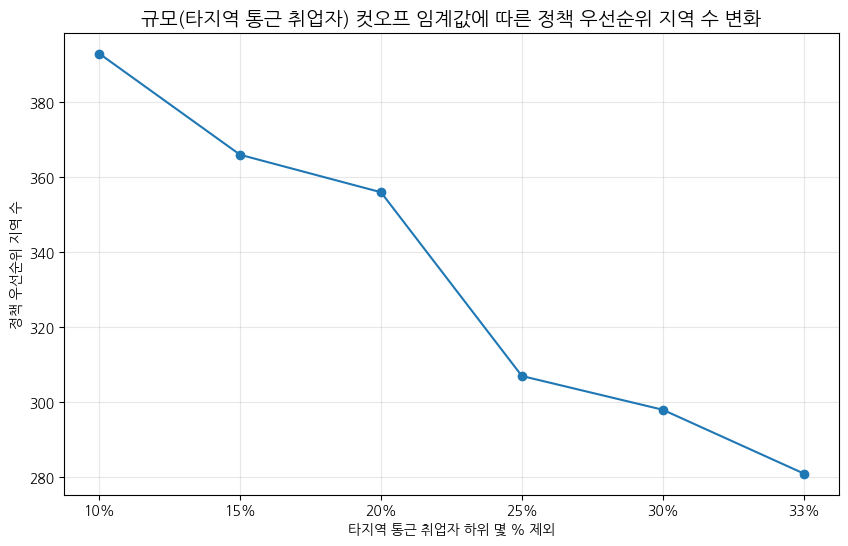

In [ ]:
# 인구 규모 필터링 임계값 민감도 분석
# -> 하위 25% 컷오프가 임의적 기준이라는 지적을 막기 위해, 다른 임계값에서도 결과가 안정적인지 확인
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.33]

sensitivity_results = []
priority_sets = {}

for q in thresholds:
    pop_cutoff = final_set[SCALE_COL].quantile(q)
    is_priority = (final_set['type'] == '저가-장통근 (이중고)') & (final_set[SCALE_COL] >= pop_cutoff)
    priority_regions = set(final_set.loc[is_priority, '행정동명'])
    priority_sets[q] = priority_regions
    sensitivity_results.append({
        '분위수 컷오프': f'{q*100:.0f}%',
        '정책 우선순위 지역 수': len(priority_regions)
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print("=== 컷오프 임계값별 정책 우선순위 지역 수 ===")
display(sensitivity_df)

# 25% 기준 대비 다른 임계값에서의 지역 목록 안정성 (자카드 유사도)
base_set = priority_sets[0.25]
print("\n=== 25% 기준 대비 자카드 유사도 (지역 목록 안정성) ===")
for q, s in priority_sets.items():
    if q == 0.25:
        continue
    jaccard = len(base_set & s) / len(base_set | s)
    print(f"{q*100:.0f}% 기준: 자카드 유사도 {jaccard:.3f}")

# 시각화
plt.figure(figsize=(10, 6))
plt.plot(sensitivity_df['분위수 컷오프'], sensitivity_df['정책 우선순위 지역 수'], marker='o')
plt.title('규모(타지역 통근 취업자) 컷오프 임계값에 따른 정책 우선순위 지역 수 변화', fontsize=14)
plt.xlabel('타지역 통근 취업자 하위 몇 % 제외')
plt.ylabel('정책 우선순위 지역 수')
plt.grid(alpha=0.3)
plt.show()


거주지외 타지역 통근 취업자 (천명) 하위 25% 기준값: 98.0천명

=== 이중고 세부 분류 분포 ===


,count
bedtown_type,
해당없음,635
이중고 (정책 우선순위),307
이중고 (소규모/참고용),186



=== '이중고 (정책 우선순위)' Top 15 (잔차 기준) ===


,행정동명,중위매매가,평균 출퇴근시간,거주지외 타지역 통근 취업자 (천명),타지역 통근 비율 (%),residual
1035,경기도 화성시 송산면,376000,135.660316,223,37.104825,50.447014
1038,경기도 화성시 장안면,376000,119.819889,223,37.104825,34.606587
478,인천광역시 연수구 송도2동,558000,115.012569,127,57.466063,34.529355
1029,경기도 화성시 우정읍,376000,117.417244,223,37.104825,32.203942
941,경기도 용인시 처인구 남사면,340500,114.708870,293,51.858407,28.572941
977,경기도 파주시 적성면,324500,115.065144,100,35.087719,28.513382
943,경기도 용인시 처인구 백암면,340500,111.986744,293,51.858407,25.850815
1030,경기도 화성시 향남읍,376000,110.369934,223,37.104825,25.156632
479,인천광역시 연수구 송도1동,558000,104.360241,127,57.466063,23.877027
468,인천광역시 연수구 옥련1동,558000,104.103535,127,57.466063,23.620321


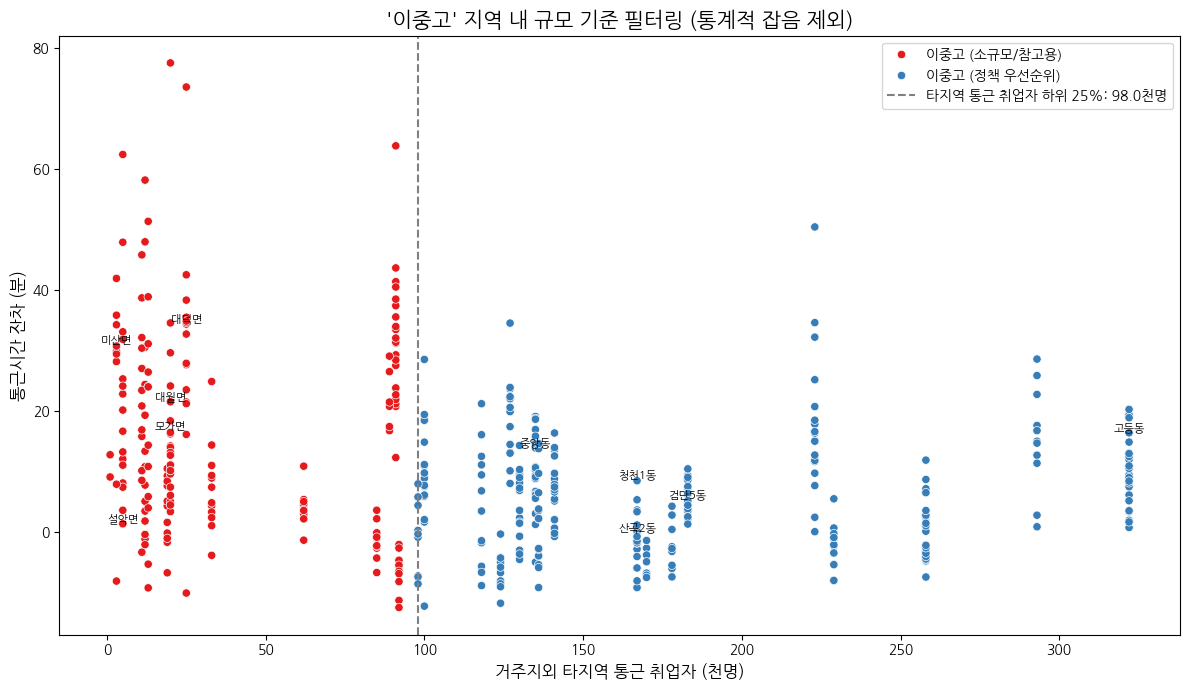

In [ ]:
# 3. 통계적 잡음 제외: 지역 규모 기준 적용
# 잔차 상위 지역 중 상당수가 인구 자체가 매우 적은 산간/소멸위기 시군구임
# -> 이런 지역은 잔차(residual)는 크게 나오지만, 실제 영향을 받는 사람 수가 적어 정책 우선순위는 낮음
# -> '거주지외 타지역 통근 취업자' 규모를 기준으로 표본이 지나치게 작은 지역을 구분해서 별도 표시

pop_q1 = final_set[SCALE_COL].quantile(0.25)
print(f"{SCALE_COL} 하위 25% 기준값: {pop_q1:.1f}천명")

def classify_scale(row):
    if row['type'] == '저가-장통근 (이중고)' and pd.isna(row[SCALE_COL]):
        return '이중고 (규모 데이터 없음)'   # 통근 데이터가 안 붙은 지역이 '정책 우선순위'로 잘못 분류되지 않도록
    elif row['type'] == '저가-장통근 (이중고)' and row[SCALE_COL] < pop_q1:
        return '이중고 (소규모/참고용)'
    elif row['type'] == '저가-장통근 (이중고)':
        return '이중고 (정책 우선순위)'
    else:
        return '해당없음'

final_set['bedtown_type'] = final_set.apply(classify_scale, axis=1)

print("\n=== 이중고 세부 분류 분포 ===")
display(final_set['bedtown_type'].value_counts())

print("\n=== '이중고 (정책 우선순위)' Top 15 (잔차 기준) ===")
priority = final_set[final_set['bedtown_type'] == '이중고 (정책 우선순위)'].sort_values('residual', ascending=False)
display(priority[['행정동명', '중위매매가', '평균 출퇴근시간', SCALE_COL, '타지역 통근 비율 (%)', 'residual']].head(15))

# 시각화: '이중고' 지역 내에서 타지역 통근 취업자 규모에 따른 세부 구분 확인
plt.figure(figsize=(12, 7))
subset = final_set[final_set['type'] == '저가-장통근 (이중고)']
sns.scatterplot(data=subset, x=SCALE_COL, y='residual', hue='bedtown_type', palette='Set1')
plt.axvline(pop_q1, color='gray', linestyle='--', label=f'타지역 통근 취업자 하위 25%: {pop_q1:.1f}천명')
plt.title("'이중고' 지역 내 규모 기준 필터링 (통계적 잡음 제외)", fontsize=15)
plt.xlabel('거주지외 타지역 통근 취업자 (천명)', fontsize=12)
plt.ylabel('통근시간 잔차 (분)', fontsize=12)
plt.legend()

# 각 subset 기준으로 5개씩 지역명 추가
# '이중고 (소규모/참고용)' 그룹에서 샘플링
subset_small = subset[subset['bedtown_type'] == '이중고 (소규모/참고용)']
if not subset_small.empty:
    sample_size_small = min(5, len(subset_small))
    random_sample_small = subset_small.sample(n=sample_size_small, random_state=42)
    for i, row in random_sample_small.iterrows():
        plt.text(row[SCALE_COL], row['residual'], row['name'],
                 fontsize=8, ha='center', va='bottom', color='black')

# '이중고 (정책 우선순위)' 그룹에서 샘플링
subset_priority = subset[subset['bedtown_type'] == '이중고 (정책 우선순위)']
if not subset_priority.empty:
    sample_size_priority = min(5, len(subset_priority))
    random_sample_priority = subset_priority.sample(n=sample_size_priority, random_state=42)
    for i, row in random_sample_priority.iterrows():
        plt.text(row[SCALE_COL], row['residual'], row['name'],
                 fontsize=8, ha='center', va='bottom', color='black')

plt.tight_layout()
plt.savefig('bedtown_scale_scatter.png', dpi=300)
plt.show()

**분석 4: WLS 분석 및 충격 규모 분석**
- WLS 가중치와 충격 규모의 곱셈 항 모두 `거주지외 타지역 통근 취업자` 기준
- 충격 규모(impact_scale) = OLS 잔차 x 타지역 통근 취업자 (WLS는 가중 시 관계가 유지되는지 확인하는 용도)

=== OLS vs WLS 계수 비교 ===
OLS  - 절편: 94.9854, 기울기: -0.000026
WLS  - 절편: 90.8889, 기울기: -0.000022

[WLS 회귀분석 요약]
                            WLS Regression Results                            
Dep. Variable:               평균 출퇴근시간   R-squared:                       0.390
Model:                            WLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     718.8
Date:                Mon, 21 Sep 2026   Prob (F-statistic):          7.28e-123
Time:                        09:24:23   Log-Likelihood:                -4845.7
No. Observations:                1128   AIC:                             9695.
Df Residuals:                    1126   BIC:                             9706.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------

,행정동명,중위매매가,평균 출퇴근시간,거주지외 타지역 통근 취업자 (천명),타지역 통근 비율 (%),residual,impact_scale
1035,경기도 화성시 송산면,376000,135.660316,223,37.104825,50.447014,11249.684159
1052,경기도 화성시 동탄6동,839500,113.815578,223,37.104825,40.648408,9064.594930
605,경기도 수원시 영통구 태장동,675000,103.782043,322,47.916667,26.339601,8481.351389
941,경기도 용인시 처인구 남사면,340500,114.708870,293,51.858407,28.572941,8371.871570
1038,경기도 화성시 장안면,376000,119.819889,223,37.104825,34.606587,7717.268850
943,경기도 용인시 처인구 백암면,340500,111.986744,293,51.858407,25.850815,7574.288651
1029,경기도 화성시 우정읍,376000,117.417244,223,37.104825,32.203942,7181.478990
610,경기도 수원시 영통구 영통2동,675000,99.676979,322,47.916667,22.234536,7159.520655
601,경기도 수원시 영통구 매탄1동,675000,98.211731,322,47.916667,20.769288,6687.710765
940,경기도 용인시 처인구 이동읍,340500,108.855328,293,51.858407,22.719398,6656.783667


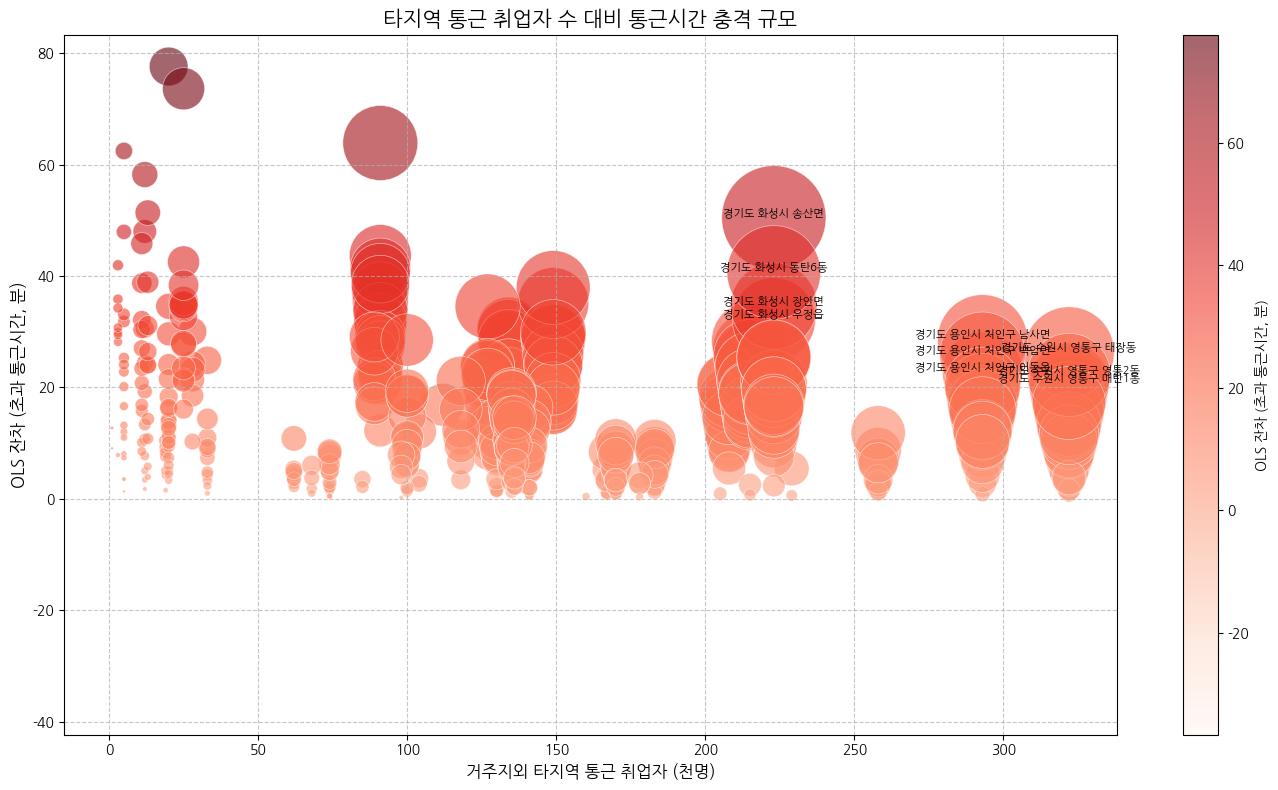

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. 가중최소제곱법(WLS) 및 충격 규모 파악 (거주지외 타지역 통근 취업자 칼럼 활용)
# 가중치: 타지역 통근 취업자 수(천명) -> 실제로 이동하는 사람이 많은 지역일수록 회귀선 추정에 더 큰 영향을 주도록 설정
# (통근 데이터가 안 붙은 행정동은 WLS 적합에서만 제외)
valid = final_set[SCALE_COL].notna()
wls_data = final_set[valid]

X_wls = sm.add_constant(wls_data['중위매매가'])
y_wls = wls_data['평균 출퇴근시간']
weights = wls_data[SCALE_COL]

wls_model = sm.WLS(y_wls, X_wls, weights=weights).fit()

print("=== OLS vs WLS 계수 비교 ===")
print(f"OLS  - 절편: {model.params['const']:.4f}, 기울기: {model.params['중위매매가']:.6f}")
print(f"WLS  - 절편: {wls_model.params['const']:.4f}, 기울기: {wls_model.params['중위매매가']:.6f}")
print("\n[WLS 회귀분석 요약]")
print(wls_model.summary())

# WLS 기준 예측값과 잔차 재계산 (전체 행정동에 대해)
X_all = sm.add_constant(final_set['중위매매가'])
final_set['predicted_commute_wls'] = wls_model.predict(X_all)
final_set['residual_wls'] = final_set['평균 출퇴근시간'] - final_set['predicted_commute_wls']

# '실질 충격 규모' = OLS 잔차(초과 통근시간) x 타지역 통근 취업자 수(천명)
# -> 해당 지역에서 발생하는 '초과 통근시간 총량'을 근사적으로 나타내는 지표 (단위: 분*천명)
# WLS 잔차가 아닌 OLS 잔차를 쓰는 이유: WLS는 가중치가 큰 지역의 잔차를 구조적으로 줄여 놓는데,
# 같은 변수를 다시 곱하면 규모가 큰 지역의 부담이 과소평가됨
final_set['impact_scale'] = final_set['residual'] * final_set[SCALE_COL]

print("\n=== 충격 규모(Impact Scale) Top 20: 실제로 다수에게 영향을 미치는 지역 ===")
top_impact = final_set.sort_values('impact_scale', ascending=False).head(20)
display(top_impact[['행정동명', '중위매매가', '평균 출퇴근시간', SCALE_COL, '타지역 통근 비율 (%)', 'residual', 'impact_scale']])

# 시각화: 타지역 통근 취업자 수 대비 OLS 잔차, 버블 크기 = 충격 규모
plot_df = final_set[valid]
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    plot_df[SCALE_COL], plot_df['residual'],
    s=plot_df['impact_scale'].clip(lower=0) / 2,   # 음수 방지
    alpha=0.6, c=plot_df['residual'], cmap='Reds',
    edgecolors='w', linewidth=0.5
)

# impact_scale이 높은 상위 10개 지역만 라벨링하여 가독성 확보
for i, row in plot_df.sort_values('impact_scale', ascending=False).head(10).iterrows():
    plt.text(row[SCALE_COL], row['residual'], row['행정동명'], fontsize=8, ha='center', va='bottom', color='black')

plt.colorbar(label='OLS 잔차 (초과 통근시간, 분)')
plt.title('타지역 통근 취업자 수 대비 통근시간 충격 규모', fontsize=15)
plt.xlabel('거주지외 타지역 통근 취업자 (천명)', fontsize=12)
plt.ylabel('OLS 잔차 (초과 통근시간, 분)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('impact_scale_scatter_with_labels.png', dpi=300)
plt.show()

**수도권 읍면동별 정책 시급도(충격 규모-impact_scale) 매핑**

병합된 GeoDataFrame (merged_gdf)의 행 개수: 1129


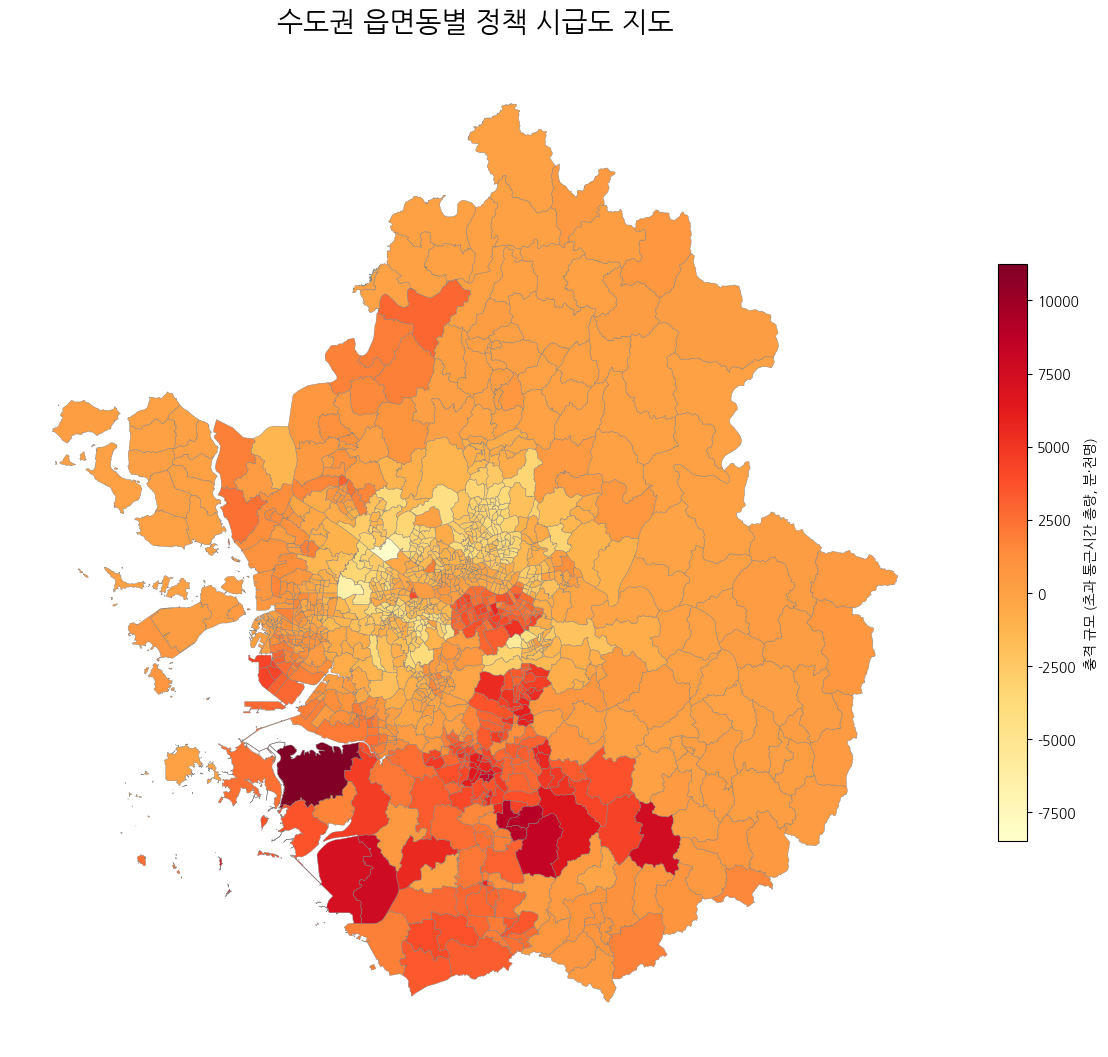

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Shapefile 지도 데이터 불러오기
shp_path = '/content/drive/MyDrive/교통문제공모전/updated_shapefile.shp'
gdf = gpd.read_file(shp_path, encoding='cp949')

# 'ADM_CD' 컬럼을 문자열로 변환
gdf['ADM_CD'] = gdf['ADM_CD'].astype(str)
# 그리고 gdf의 ADM_CD와 길이를 맞추기 위해 7자리 코드에 '0'을 추가 (예: '1101053' -> '11010530')
final_set['행정동별 코드'] = final_set['행정동별 코드'].astype(str).str.replace('\r', '', regex=False)

# 2. 수도권(서울, 인천, 경기) 데이터만 필터링하기 (11: 서울, 23: 인천, 31: 경기)
# 앞 2자리 코드를 추출하여 수도권만 남기기
gdf['sido_code'] = gdf['ADM_CD'].str[:2]
gdf_metro = gdf[gdf['sido_code'].isin(['11', '23', '31'])]

# 3. 지도 데이터(GeoDataFrame)와 통근 데이터(DataFrame) 병합
# 지도 데이터의 읍면동 코드와 CSV의 읍면동 코드를 기준으로 조인
merged_gdf = gdf_metro.merge(final_set, left_on='ADM_CD', right_on='행정동별 코드', how='inner')
print(f"병합된 GeoDataFrame (merged_gdf)의 행 개수: {len(merged_gdf)}")

# 4. 단계구분도(Choropleth Map) 그리기
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지 크기 설정
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 시각화 실행
merged_gdf.plot(
    column='impact_scale',         # 시각화할 통근 데이터의 수치 컬럼명 입력
    ax=ax,
    cmap='YlOrRd',                # 색상 지도 (Yellow-Orange-Red)
    legend=True,
    legend_kwds={'shrink': 0.5, 'label': "충격 규모 (초과 통근시간 총량, 분·천명)"}, # 범례 설정
    edgecolor='gray',             # 읍면동 경계선 색상
    linewidth=0.3,                # 경계선 두께
    missing_kwds={'color': 'lightgrey',
                  "hatch": "////"} # 데이터가 없는 지역의 색상
)

plt.title('수도권 읍면동별 정책 시급도 지도', fontsize=20, fontweight='bold', pad=20)
ax.set_axis_off() # 지저분한 X, Y축 좌표선 숨기기

# 결과물 이미지로 저장
plt.savefig('수도권_읍면동별_정책시급도_지도.png', dpi=300, bbox_inches='tight')
plt.show()